## Table of Contents

- [1. Supervised Learning (Course 1)](#1-supervised-learning-course-1)
- [2. Advanced Learning Algorithms (Course 2)](#2-advanced-learning-algorithms-course-2)
- [3. Unsupervised Learning, Recommenders & Reinforcement Learning (Course 3)](#3-unsupervised-learning-recommenders--reinforcement-learning-course-3)
- [4. Statistics / Math for ML](#4-statistics--math-for-ml)
- [5. Deep Learning (Out of scope — not day-1 relevant)](#5-deep-learning-out-of-scope--not-day-1-relevant)

## 1. Supervised Learning (Course 1)
- Difference between loss function and cost function?
- How does regularisation add penalty term to the loss function? How does this perform mathematically (how it adjusts when the model is going to under-fit or overfit?)?
- How do we perform normalisation on data with multiple features? Show a coding example.
- When do you perform one-hot encoding? Specifically does it only apply to binary data or can we use this for continuous values?
- When do we RMSE? Is it the same as using MSE? If so, show me through code variations (in library).
- What is r-squared and what is its relevance to ML?
- How do we decide to choose between L1 and L2? What does it mean when L1 induces sparsity while L2 regularises weights? Since L2 is better than L1, why bother using L1?
- Difference between alpha and regularisation?
- What are other Gradient Descent methods? And when do we use them in ML?
- Explain SVM thoroughly.

## 2. Advanced Learning Algorithms (Course 2)
- When and how do we use bias and variance in ML?
- When do you perform oversampling and how? Is it for classification task where there are fewer datapoint in a certain class than others?

## 3. Unsupervised Learning, Recommenders & Reinforcement Learning (Course 3)
- How does the transformation of data for PCA help in ML? Which step does PCA come in when performing ML?
- What type of machine learning is Recommendation?
- What is Markov Chains and why do we need them in ML?
- How to perform anomaly detection in ML programming?

## 4. Statistics / Math for ML
- Why do we need to know if a dataset normally distributed? What kind of ML uses it?
- What is and why do we need hypothesis testing in ML?
- What is and why do we need t-test in ML?
- Explain shortly what Bayes Theorem is. Then explain to me how it is applicable in ML.

## 5. Deep Learning (Out of scope — not day-1 relevant)
- Where do we use transfer learning?
- When do we do knowledge transfer for machine learning? And how does one perform this in coding?

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# make_classification generates a synthetic dataset for classification tasks —
# useful here because it's fast, clean, and lets us control exactly how "learnable" it is
X, y = make_classification(
    n_samples=500,        # total number of rows (data points) to generate
    n_features=10,        # total number of columns (features) per row
    n_informative=6,      # how many of those features actually carry signal (predictive of y)
    n_redundant=2,        # how many features are linear combinations of the informative ones (fake signal, tests regularization)
    n_classes=2,          # binary classification (0 or 1)
    weights=[0.7, 0.3],   # class balance — 70% class 0, 30% class 1 (mimics imbalance like SECOM pass/fail)
    random_state=42       # seed for reproducibility — same seed = same "random" data every run
)

# train_test_split separates data into a training set (to fit the model)
# and a test set (to evaluate it on unseen data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% of data held out for testing, 80% for training
    random_state=42    # same seed ensures the same split every time you rerun
)

print(X_train.shape, X_test.shape)

# 1. Supervised Learning (Course 1)

### How does regularisation add penalty term to the loss function?

Regularization is added to the **cost function** (not the per-example loss), as an extra penalty term based on the model's weights:

- **L2 (Ridge):** $J(w,b) = \frac{1}{m}\sum L(\hat{y}^{(i)}, y^{(i)}) + \frac{\lambda}{2m}\sum_{j} w_j^2$
- **L1 (Lasso):** $J(w,b) = \frac{1}{m}\sum L(\hat{y}^{(i)}, y^{(i)}) + \frac{\lambda}{m}\sum_{j} |w_j|$

`alpha` (or `λ`/lambda in Ng's notation) is the **regularization strength**. Higher alpha = simpler model (more bias, less variance). Alpha = 0 means no regularization.

**Careful:** in `LogisticRegression`, sklearn uses `C` instead of `alpha`, and `C` is the **inverse** of regularization strength (`C = 1/λ`). Smaller `C` = stronger regularization.

**Key parameters:**
- `alpha` (Ridge/Lasso/ElasticNet) — regularization strength, tune via `RidgeCV`/`GridSearchCV`
- `C` (LogisticRegression, SVC) — inverse regularization strength
- `penalty` — `'l1'`, `'l2'`, `'elasticnet'`, or `None`
- `solver` — `'liblinear'` supports L1, `'lbfgs'` (default) only supports L2

[⬆ Back to top](#table-of-contents)

**Code:** Fitting Ridge (L2) and Lasso (L1) regression models and comparing their learned coefficients.

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Note: Ridge/Lasso are regression models. Our y_train is binary (0/1) from
# make_classification, so this is just to illustrate how alpha affects the
# coefficients numerically — not a meaningful classification model.

# Ridge = L2 regularization
ridge = Ridge(
    alpha=1.0   # regularization strength (this is lambda). Higher = more shrinkage, simpler model
)
ridge.fit(X_train, y_train)

# Lasso = L1 regularization
lasso = Lasso(
    alpha=1.0,      # same role as Ridge's alpha, but L1 penalty can push coefficients to exactly 0
    max_iter=10000  # Lasso uses an iterative solver (coordinate descent) — raised so it converges
)
lasso.fit(X_train, y_train)

print("Ridge coefficients:", ridge.coef_)  # coef_ = the learned weight for each feature
print("Lasso coefficients:", lasso.coef_)  # compare: some Lasso coefficients may be exactly 0.0

**Code:** Fitting a regularized logistic regression classifier and inspecting its learned weights.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    penalty='l2',     # type of regularization: 'l1', 'l2', 'elasticnet', or None
    C=1.0,             # inverse regularization strength (C = 1/alpha) — smaller C = stronger regularization
    solver='lbfgs',    # optimization algorithm used to fit the model; 'lbfgs' only supports l2/None
    max_iter=1000      # max number of iterations for the solver to converge
)
model.fit(X_train, y_train)

print("Coefficients:", model.coef_)  # one weight per feature
print("Intercept:", model.intercept_)  # the bias term

**Code:** Visualizing how increasing alpha shrinks coefficients differently for Ridge (L2) vs Lasso (L1) — this is where you can *see* Lasso's sparsity property (coefficients hitting exactly 0) vs Ridge's smooth shrinkage.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso

# Test a range of alpha values, log-spaced since regularization effects are non-linear
alphas = np.logspace(-3, 2, 50)  # 50 values from 0.001 to 100

ridge_coefs = []  # will hold the weight vector at each alpha, for Ridge
lasso_coefs = []  # same, for Lasso

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    ridge_coefs.append(ridge.coef_)

    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train, y_train)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)  # shape: (n_alphas, n_features)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 side-by-side plots

axes[0].plot(alphas, ridge_coefs)
axes[0].set_xscale('log')  # log scale x-axis since alpha spans orders of magnitude
axes[0].set_xlabel('alpha (regularization strength)')
axes[0].set_ylabel('coefficient value')
axes[0].set_title('Ridge (L2): coefficients shrink smoothly toward 0')

axes[1].plot(alphas, lasso_coefs)
axes[1].set_xscale('log')
axes[1].set_xlabel('alpha (regularization strength)')
axes[1].set_ylabel('coefficient value')
axes[1].set_title('Lasso (L1): coefficients hit exactly 0 (sparsity)')

plt.tight_layout()
plt.show()

### How do we perform normalisation on data with multiple features? What is standardisation for, and does it do the same thing?

**Normalisation** rescales feature values onto a common range (commonly [0,1]), so that no single feature dominates a model just because of its raw magnitude (e.g. "salary in dollars" vs. "age in years").

**Standardisation** rescales each feature to have **mean = 0** and **standard deviation = 1** (z-score scaling): z = (x - mean) / std.

**Functionally different, not the same:**

| | Normalisation (MinMaxScaler) | Standardisation (StandardScaler) |
|---|---|---|
| Output range | Fixed, e.g. [0,1] | Unbounded — centered at 0 |
| Sensitive to outliers | Yes — a single extreme value compresses everything else | Less sensitive, but still affected |
| Assumes normal distribution | No | Works best when data is roughly Gaussian, not strictly required |
| Best for | Algorithms needing bounded input (e.g. neural net inputs) | Algorithms assuming centered data (PCA, linear/logistic regression, SVM, distance/gradient-based methods) |

**Rule of thumb:** standardisation is the more common default in classical ML — especially before PCA, since PCA looks for directions of maximum variance, and unscaled features with larger raw ranges would dominate the variance calculation artificially.

**With multiple features:** each feature is scaled **independently**, using only that feature's own min/max (or mean/std) — not across features. A dataset with 10 features gets 10 separate column-wise transformations.

**When to use either:** gradient descent-based models (linear/logistic regression, neural nets), distance-based models (KNN, K-means, SVM), and PCA. Tree-based models (Random Forest, XGBoost) generally don't need scaling, since splits are based on order, not magnitude.

**Pipeline stage:** both are **preprocessing / feature engineering** steps, done **after train/test split, before model fitting**:

`Raw data → Train/test split → Fit scaler on train only → Transform train & test → Fit model on scaled train data → Evaluate on scaled test data`

Fitting a scaler on the full dataset (before splitting) causes **data leakage** — the scaler would "see" test data statistics during training, giving an overly optimistic evaluation later.

**Practical note for SECOM:** with 591 features on different sensor scales, scaling isn't optional — it's a required step before PCA or any distance/gradient-based model.

**Code:** Applying MinMaxScaler to scale multiple features into the [0,1] range, and comparing feature ranges before vs. after.

In [13]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# MinMaxScaler rescales each feature independently to a target range (default 0 to 1)
# formula per feature: (x - min) / (max - min)
scaler = MinMaxScaler(
    feature_range=(0, 1)  # target range after scaling — (0,1) is standard, but can be changed e.g. (-1,1)
)

# IMPORTANT: fit the scaler ONLY on training data (learns min/max from X_train),
# then use the SAME fitted scaler to transform test data — this avoids data leakage
X_train_minmax = scaler.fit_transform(X_train)   # learns min/max AND transforms in one step
X_test_minmax = scaler.transform(X_test)         # only transforms, using min/max learned from X_train

print("Before scaling — min/max per feature (train):")
print(np.round(X_train.min(axis=0), 2))
print(np.round(X_train.max(axis=0), 2))

print("\nAfter scaling — min/max per feature (train):")
print(np.round(X_train_minmax.min(axis=0), 2))  # should all be ~0.0
print(np.round(X_train_minmax.max(axis=0), 2))  # should all be ~1.0

Before scaling — min/max per feature (train):
[-5.   -4.33 -2.63 -4.66 -5.44 -6.47 -2.93 -6.8  -4.59 -4.93]
[4.94 6.01 2.87 5.07 3.62 8.35 3.24 5.28 6.56 3.1 ]

After scaling — min/max per feature (train):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


**Code:** Visualizing feature scales before vs. after normalisation.

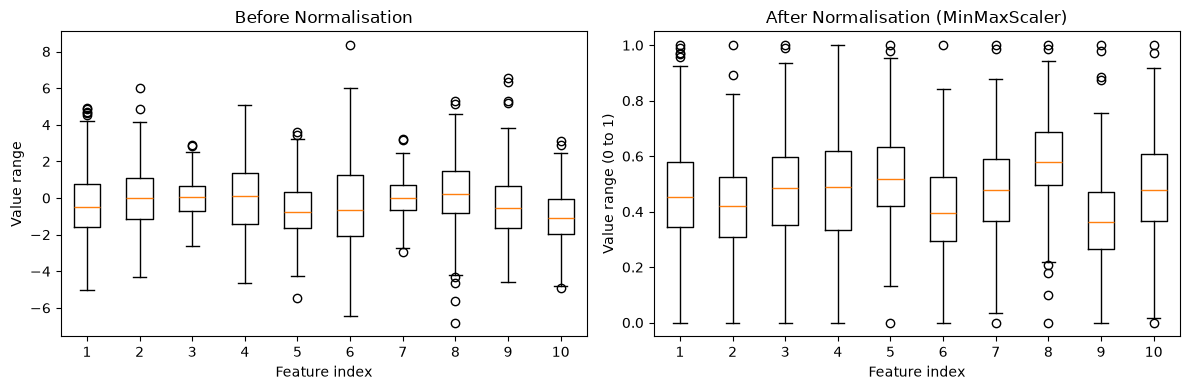

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot before scaling — features on very different scales are hard to compare
axes[0].boxplot(X_train)
axes[0].set_title('Before Normalisation')
axes[0].set_xlabel('Feature index')
axes[0].set_ylabel('Value range')

# Boxplot after scaling — all features now sit within [0, 1]
axes[1].boxplot(X_train_minmax)
axes[1].set_title('After Normalisation (MinMaxScaler)')
axes[1].set_xlabel('Feature index')
axes[1].set_ylabel('Value range (0 to 1)')

plt.tight_layout()
plt.show()

**Code:** Applying StandardScaler instead, and comparing its output distribution to MinMaxScaler's — this shows the key difference: StandardScaler centers at 0 with no fixed upper/lower bound, while MinMaxScaler is bounded to [0,1].

StandardScaler — mean per feature (train, should be ~0):
[ 0. -0.  0. -0. -0.  0.  0.  0.  0. -0.]
StandardScaler — std per feature (train, should be ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


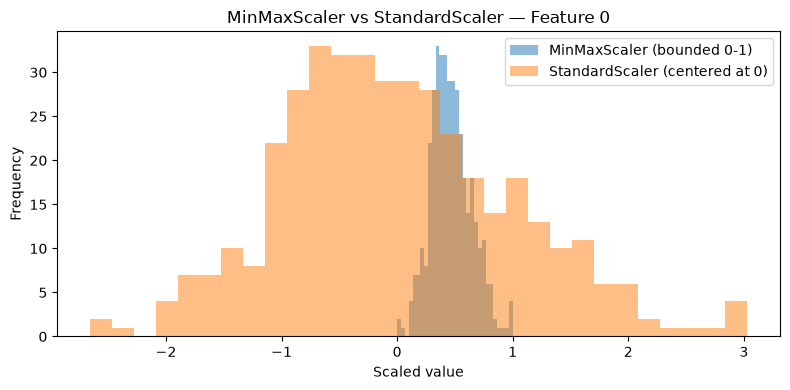

In [15]:
from sklearn.preprocessing import StandardScaler

# StandardScaler transforms each feature to mean=0, std=1
# formula per feature: (x - mean) / std
std_scaler = StandardScaler()

X_train_std = std_scaler.fit_transform(X_train)  # fit on train only, then transform
X_test_std = std_scaler.transform(X_test)        # transform test using train's mean/std

print("StandardScaler — mean per feature (train, should be ~0):")
print(np.round(X_train_std.mean(axis=0), 2))
print("StandardScaler — std per feature (train, should be ~1):")
print(np.round(X_train_std.std(axis=0), 2))

# Side-by-side comparison of the two scaling methods on the same feature
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(X_train_minmax[:, 0], bins=30, alpha=0.5, label='MinMaxScaler (bounded 0-1)')
ax.hist(X_train_std[:, 0], bins=30, alpha=0.5, label='StandardScaler (centered at 0)')
ax.set_xlabel('Scaled value')
ax.set_ylabel('Frequency')
ax.set_title('MinMaxScaler vs StandardScaler — Feature 0')
ax.legend()
plt.tight_layout()
plt.show()

### When do you perform one-hot encoding? Does it apply only to binary data, or can it be used for continuous values?

**One-hot encoding** converts a **categorical** feature (a column with discrete, non-numeric or non-ordinal categories) into multiple binary (0/1) columns — one column per category. E.g. a `color` column with values `red`, `blue`, `green` becomes 3 columns: `color_red`, `color_blue`, `color_green`, each 0 or 1.

**When to use it:** only on **categorical** (nominal) features — i.e. features where the categories have **no inherent order** (color, country, machine ID, defect type). It's not limited to binary categories — it works for any number of categories (2, 3, 50, etc.), though with very high cardinality (hundreds of categories) it creates a lot of sparse columns, which can hurt some models.

**Does NOT apply to continuous values.** Continuous numeric features (age, temperature, sensor reading) should be scaled (normalisation/standardisation), not one-hot encoded — one-hot encoding treats each unique value as a separate category, which is meaningless (and computationally disastrous) for continuous data.

**Important distinction — nominal vs. ordinal categories:**
- **Nominal** (no order, e.g. `red/blue/green`) → one-hot encoding
- **Ordinal** (has order, e.g. `low/medium/high`) → often better as **ordinal/label encoding** (0, 1, 2), preserving the rank, since one-hot encoding would throw away that ordering information

**Pipeline stage:** preprocessing / feature engineering — same stage as scaling, done **after train/test split** (fit the encoder on train categories only, to avoid leaking unseen category info from test into train).

**Code:** One-hot encoding a categorical feature, and comparing it to ordinal (label) encoding for an ordinal feature — showing why the choice depends on whether the categories have order.

In [16]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Small example DataFrame — separate from X_train/X_test since this needs
# categorical columns, which our synthetic numeric dataset doesn't have
df = pd.DataFrame({
    'machine_id': ['M1', 'M2', 'M3', 'M1', 'M2'],       # nominal — no order → one-hot encode
    'defect_severity': ['low', 'high', 'medium', 'low', 'high']  # ordinal — has order → ordinal encode
})

# --- One-hot encoding (for nominal category: machine_id) ---
ohe = OneHotEncoder(
    sparse_output=False,   # return a regular dense array instead of a sparse matrix (easier to read here)
    handle_unknown='ignore'  # if test data has a category not seen in train, encode it as all-zeros instead of erroring
)
machine_encoded = ohe.fit_transform(df[['machine_id']])  # fit_transform expects a 2D input, hence [[...]]
machine_encoded_df = pd.DataFrame(
    machine_encoded,
    columns=ohe.get_feature_names_out(['machine_id'])  # generates column names like machine_id_M1, machine_id_M2...
)
print("One-hot encoded (machine_id):")
print(machine_encoded_df)

# --- Ordinal encoding (for ordinal category: defect_severity) ---
ordinal = OrdinalEncoder(
    categories=[['low', 'medium', 'high']]  # explicitly define the order — otherwise sklearn picks alphabetical, which may be wrong
)
severity_encoded = ordinal.fit_transform(df[['defect_severity']])
print("\nOrdinal encoded (defect_severity), low=0, medium=1, high=2:")
print(severity_encoded.flatten())

One-hot encoded (machine_id):
   machine_id_M1  machine_id_M2  machine_id_M3
0            1.0            0.0            0.0
1            0.0            1.0            0.0
2            0.0            0.0            1.0
3            1.0            0.0            0.0
4            0.0            1.0            0.0

Ordinal encoded (defect_severity), low=0, medium=1, high=2:
[0. 2. 1. 0. 2.]


**Code:** Using pandas' get_dummies as a quicker alternative to sklearn's OneHotEncoder for simple one-off encoding.

In [17]:
# pd.get_dummies is a simpler pandas shortcut for one-hot encoding —
# convenient for quick EDA, but sklearn's OneHotEncoder is preferred inside
# a proper ML pipeline (it can fit on train and transform test consistently)
dummies = pd.get_dummies(
    df['machine_id'],
    prefix='machine_id'  # prefix added to each new column name
)
print(dummies)

   machine_id_M1  machine_id_M2  machine_id_M3
0           True          False          False
1          False           True          False
2          False          False           True
3           True          False          False
4          False           True          False


### When do you perform oversampling, and is it for classification tasks with fewer datapoints in a certain class?

**Oversampling** is a technique to address **class imbalance** in classification tasks — where one class has significantly fewer examples than another (e.g. SECOM: far more "pass" than "fail" samples). It works by **increasing the number of minority-class samples** (either duplicating them or generating synthetic ones) so the model doesn't just learn to always predict the majority class.

**When to use it:** whenever your classification target is imbalanced enough that a naive model could get high accuracy just by ignoring the minority class entirely.

**What is a "naive model" here?** A naive model is one that predicts the **majority class every single time**, with no actual learning involved — e.g. always predicting "pass." If 95% of SECOM samples are "pass," this naive strategy gets 95% accuracy while being completely useless (it never catches a single defect). This is why accuracy alone is a misleading metric on imbalanced data, and why oversampling (plus metrics like precision/recall/F1) matters — you want the model to actually learn to distinguish classes, not just exploit the imbalance.

This is extremely common in fault/defect detection (like SECOM), fraud detection, and rare disease diagnosis — the class you actually care about (the "fail"/"fraud"/"disease" case) is usually the rare one.

**Yes** — it's specifically a classification concept, applied when there are fewer datapoints in one class relative to others.

**Main oversampling methods:**
- **Random oversampling** — duplicates existing minority-class rows at random (simple, but risks overfitting since it doesn't add new information, just repeats it)
- **SMOTE** (Synthetic Minority Oversampling Technique) — generates *new*, synthetic minority-class samples by interpolating between existing minority samples and their nearest neighbours, rather than just copying

**Alternative approach — undersampling:** instead of adding minority samples, you can remove majority-class samples. Usually a trade-off: oversampling risks overfitting, undersampling risks throwing away useful majority-class information. In practice, both are often combined.

**Pipeline stage:** this happens **after train/test split, on the training set only** — never on the test set, since oversampling the test set would give a misleadingly optimistic evaluation. The order is: split → oversample training data → fit model on oversampled training data → evaluate on the untouched, original-distribution test set.

**Code:** Applying SMOTE to oversample the minority class in our training set, and comparing class distribution before vs. after.

In [18]:
from imblearn.over_sampling import SMOTE
import numpy as np

# Check class distribution before oversampling
unique, counts = np.unique(y_train, return_counts=True)
print("Before SMOTE:", dict(zip(unique, counts)))

# SMOTE generates synthetic minority-class samples by interpolating between
# a minority sample and its nearest minority-class neighbours
smote = SMOTE(
    sampling_strategy='auto',  # 'auto' oversamples the minority class to match the majority class count
    k_neighbors=5,              # how many nearest neighbours to consider when generating synthetic points
    random_state=42             # reproducibility
)

# fit_resample returns a NEW, balanced training set — only apply to TRAINING data, never test data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

unique, counts = np.unique(y_train_smote, return_counts=True)
print("After SMOTE:", dict(zip(unique, counts)))

ModuleNotFoundError: No module named 'imblearn'